# Get starting with LangChain

This notebook was created when I was studying the LangChain library based in the book **Generative AI with LangChain, Second Edition** of the authors *Bean Aufffart* and *Leonid Kuligin*. The book is based on LangChain version 0.37.

## Preparing the API to Google's Gemini

I only have an API key for Google's Gemini, so every example will run on that model or in local model. The file that configures needs to contain the following code:

```python
import os

GOOGLE_API_KEY = "..."

def set_environment():
    variable_dict = globals().items()

    for key, value in variable_dict:
        if "API" in key or "ID" in key:
            os.environ[key] = value
```

I will not upload this file to not risk of leak my own API key. The file `config.py` is listed on `.gitignore`.

So, all you need to do is to run the following code to enable all the API keys required to this notebook.

In [5]:
# setting the environment variables, the keys
import sys
import os

from IPython.core.debugger import prompt
from langchain_core.messages import HumanMessage

sys.path.insert(0, os.path.abspath('..'))

from config import set_environment
# for the keys - as explained early in chapter 2
set_environment()

## Run tasks on Google's Gemini

Here are simple codes that run simple tasks in Google's Gemini model:

In [6]:
from langchain_google_genai import GoogleGenerativeAI

gemini_pro = GoogleGenerativeAI(model="gemini-2.0-flash")

response = gemini_pro.invoke("Tell me a joke about Java Programming language.")
print(response)

Why did the Java developer wear glasses?

Because he didn't C#!



### Using Chat Templates

Here I will use chat templates objects to interact with the model.

In [24]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage

# Notice that the template configures 2 separated tuples, configuring two attributes: system and user.
template = ChatPromptTemplate.from_messages([
    ("system", "You are an experienced programmer and mathematical analyst."),
    ("user", "{problem}")
])

# Here I configure the custom Google chat object. Every object has properties to configure it.
chat = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    max_output_tokens=400,
)

# Create a chain of invocations. Here it will invoke template and then chat
chain  = template | chat

problem = "Design an algorithm in R, using dplyr library, to clean a dataset of missing values."

# Notice that we invoke the chain
# response = chat.invoke([HumanMessage(content=problem)]) -> This is hwo we invoke directly in the chat object
response = chain.invoke({ "problem": problem })

print(response.content)

```R
# Algorithm: Clean Dataset of Missing Values using dplyr

# This algorithm provides a flexible and customizable approach to handling missing values
# in a dataset using the dplyr package in R.  It allows for different strategies
# for different columns and data types.

# Prerequisites:
# 1. Install the dplyr package: install.packages("dplyr")

# Input:
# - data: A data frame containing missing values (NA).
# - missing_value_strategy: A list specifying the strategy for handling missing values.
#   Each element of the list corresponds to a column in the data frame.
#   The names of the list elements should match the column names in the data frame.
#   Possible strategies include:
#     - "omit": Remove rows with missing values in this column.
#     - "mean": Replace missing values with the mean of the column (numeric columns only).
#     - "median": Replace missing values with the median of the column (numeric columns only).
#     - "mode": Replace missing values with the mode of th

### Using LangChain Expression Language (LCEL)

LCEL helps us to create a chain of invocation when running tasks on models.

Here is a simple workflow using LCEL:

In [26]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

# Create all the components that will be part of the chain of invocation
prompt = PromptTemplate.from_template("Tell me a joke about {topic}")
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", max_output_tokens=400)
output_parser = StrOutputParser()

# Create the chain
chain = prompt | llm | output_parser

# Execute the workflow(chain) with a single call
result = chain.invoke({'topic': 'dogs'})
print(result)

Why are dogs such bad dancers?

Because they have two left feet! ...And they can't tell their tail from their tutu!



Here is a more complex chain. In this new chain, we will invoke a model with the response of another task.

In [30]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.runnables import RunnablePassthrough

# Create all the components that will be part of the chain of invocation
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
output_parser = StrOutputParser()

# First chain: create a story
story_prompt = PromptTemplate.from_template("Write me a short story about {topic}")
story_chain  = story_prompt | llm | output_parser

# Second chain: analyze the story
analyze_story_prompt = PromptTemplate.from_template("Analyze the following story's mood:\n {story}")
analyze_story_chain  = story_prompt | llm | output_parser

# Combine both chains
# story_with_analyze_chain = story_chain | analyze_story_chain # This way we lost the story, just getting the resulting analysis.
story_with_analyze_chain = RunnablePassthrough.assign(story = story_chain).assign(analysis=analyze_story_chain)

story_with_analyze_result = story_with_analyze_chain.invoke({ "topic": "a raining day at school"})
print(story_with_analyze_result.keys())
print("\n\n Here is the story: \n", story_with_analyze_result["story"])
print("\n\n Here is the analysis: \n", story_with_analyze_result["analysis"])

dict_keys(['topic', 'story', 'analysis'])


 Here is the story: 
 The sky was a bruised plum color, heavy and low. Rain lashed against the windows of Mrs. Gable's third-grade classroom, blurring the world outside into a watercolor wash of grey and green. A collective groan rippled through the room as the recess bell rang, followed by a disappointed sigh. No kickball today. No chasing butterflies in the meadow. Just the soggy, echoing confines of the gymnasium.

Lily slumped in her seat, tracing patterns on her desk with her fingertip. She loved rainy days, usually. The comforting drumming on the roof, the smell of wet earth, the excuse to curl up with a book. But at school, rain was just a nuisance, a barrier to freedom.

"Alright, everyone," Mrs. Gable announced, her voice a bright spot in the gloom. "Line up quietly for the gym. And remember, inside voices!"

The gymnasium was a cacophony of bouncing basketballs, squeaking sneakers, and the echoing yells of forty restless children. L

## LangChain Fundamentals

### State Management

#### Creating a simple LangGraph

Fist step to handle state management, I need to create a object that handle the state. In this case, I will use a object called *JobApplicationState*, to handle a task related to job application, dã.

In [7]:
from typing_extensions import TypedDict

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str

Now I will create a state graph using LangGraph. Notice that for each node, I create a function:

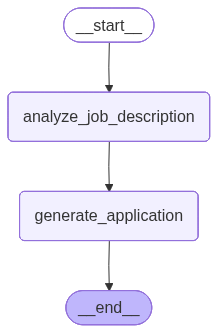

In [8]:
from langgraph.graph import StateGraph, START, END, Graph

def analyze_job_description(state):
    """
    Notice that the method return a JSON with the attribute is_suitable
    filled with True/False based in the length of the job_description
    variable.
    """
    print("...Analyzing a provided job description ...")
    return {"is_suitable": len(state["job_description"]) > 100}

def generate_application(state):
    """
    Generate a JSON with a fake application name.
    """
    print("...generating application...")
    return {"application": "some_fake_application"}

# Now let's create the StateGraph.
builder = StateGraph(JobApplicationState)

# The nodes added are exactly the function that was created before.
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)

# The edges are like connections between nodes.
builder.add_edge(START, "analyze_job_description")
builder.add_edge("analyze_job_description", "generate_application")
builder.add_edge("generate_application", END)

# A graph is a StateGraph compiled, after all the configuration.
graph = builder.compile()

# We can visualize the graph with this code:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Let's run a fake application request (notice that since the job_description length is < 100, the is_suitable variable will be false:

In [11]:
response = graph.invoke({"job_description": "fake_jd"})
print(response)

...Analyzing a provided job description ...
...generating application...
{'job_description': 'fake_jd', 'is_suitable': False, 'application': 'some_fake_application'}


#### Create a conditional edge in LangGraph

This time I will create a conditional edge in the graph.

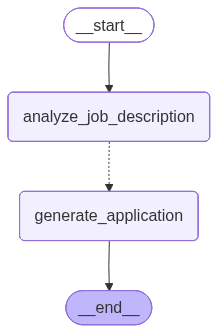

In [15]:
from typing import Literal

# Now let's create the StateGraph.
builder = StateGraph(JobApplicationState)

# The nodes added are exactly the function that was created before.
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)

def is_suitable_condition(state: JobApplicationState) -> Literal["generate_application", END]:
    """
    This edge condition returns  "generate_application" if the is_suitable equals True, or
    END if the is_suitable equals False.
    Notice that all the possible returns are listed in the return type
    """
    if state.get("is_suitable"):
        return "generate_application"
    return END

# The edges are like connections between nodes. Notice that the seconde edge is a conditional one
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges("analyze_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

# A graph is a StateGraph compiled, after all the configuration.
graph = builder.compile()

# We can visualize the graph with this code:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


Notice that the rendered graph picture is missing a dotted line from analyze_job_description to END. Maybe this is a bug of the library versions that I'm using here.

In [16]:
response = graph.invoke({"job_description": "fake_jd"})
print(response)

...Analyzing a provided job description ...
{'job_description': 'fake_jd', 'is_suitable': False}
